In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive"):
    if "Titanic-Dataset.csv" in files:
        print(os.path.join(root, "Titanic-Dataset.csv"))

/content/drive/MyDrive/titanic/Titanic-Dataset.csv


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/titanic/Titanic-Dataset.csv"

df = pd.read_csv(file_path)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Handle missing Age values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Drop Cabin because most values are missing
df = df.drop("Cabin", axis=1)

# Handle missing Embarked values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Check missing values again
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# Count passengers who survived and did not survive
survival_count = df["Survived"].value_counts()

print("Survival Count:")
print(survival_count)

print("\nSurvival Percentage:")
print(df["Survived"].value_counts(normalize=True) * 100)

Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

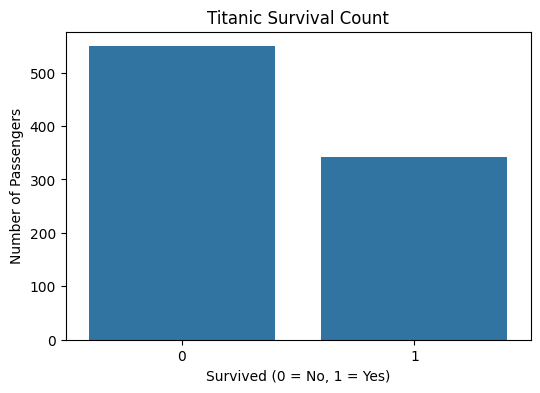

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Survived", data=df)

plt.title("Titanic Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
gender_survival = df.groupby("Sex")["Survived"].mean() * 100

print("Survival Rate by Gender:")
print(gender_survival)

Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


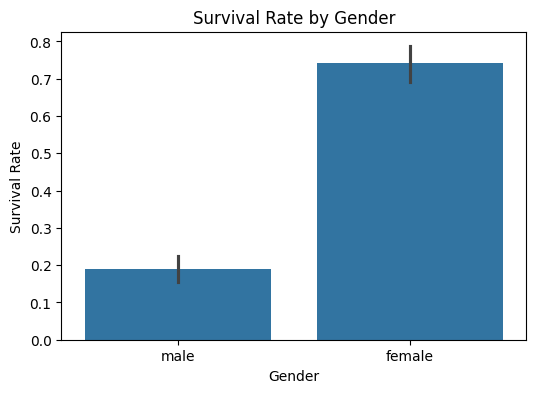

In [ ]:
plt.figure(figsize=(6, 4))

sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
class_survival = df.groupby("Pclass")["Survived"].mean() * 100

print("Survival Rate by Passenger Class:")
print(class_survival)

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


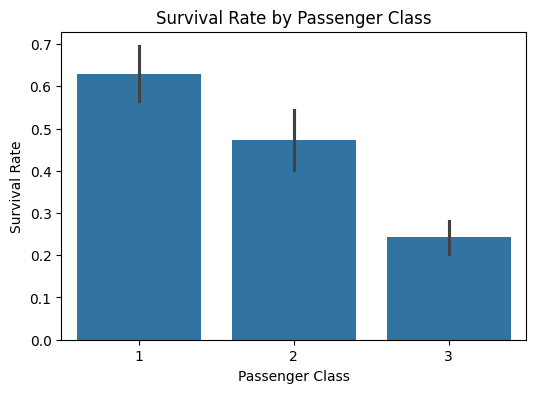

In [ ]:
plt.figure(figsize=(6, 4))

sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

# Calculate survival rate by age group
age_survival = df.groupby("AgeGroup", observed=True)["Survived"].mean() * 100

print("Survival Rate by Age Group:")
print(age_survival)

Survival Rate by Age Group:
AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


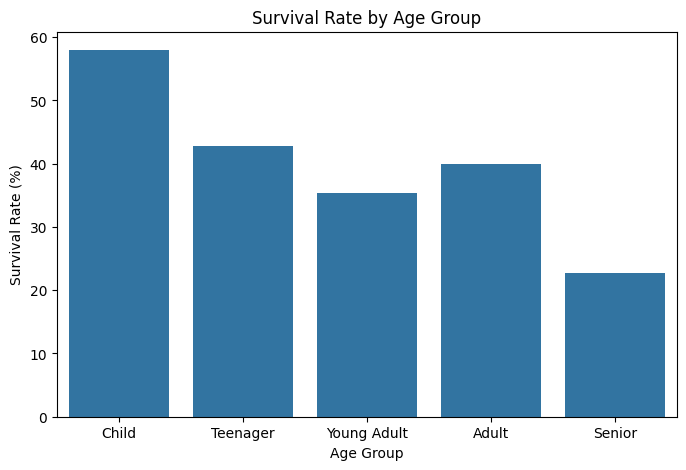

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_survival.index,
    y=age_survival.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

plt.show()

In [ ]:
embarked_survival = df.groupby("Embarked")["Survived"].mean() * 100

print("Survival Rate by Embarkation Point:")
print(embarked_survival)

Survival Rate by Embarkation Point:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


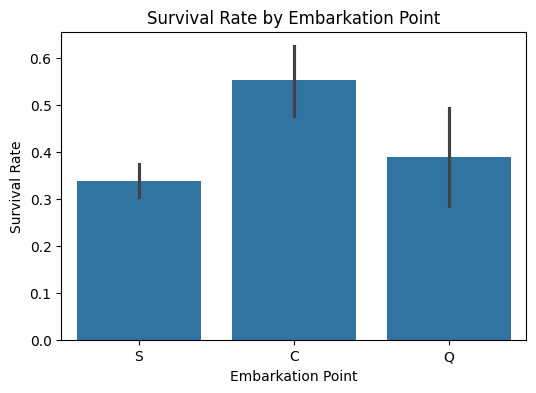

In [ ]:
plt.figure(figsize=(6, 4))

sns.barplot(x="Embarked", y="Survived", data=df)

plt.title("Survival Rate by Embarkation Point")
plt.xlabel("Embarkation Point")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
# Create Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Calculate survival rate
family_survival = df.groupby("FamilySize")["Survived"].mean() * 100

print("Survival Rate by Family Size:")
print(family_survival)

Survival Rate by Family Size:
FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


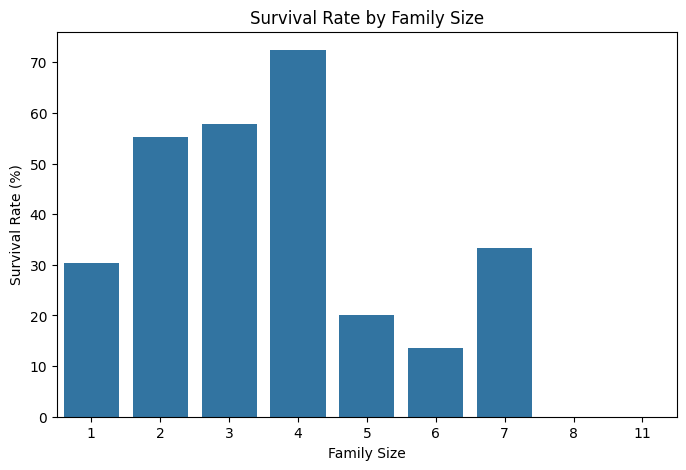

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

In [ ]:
# Overall Survival Summary

total_passengers = len(df)
survived = df["Survived"].sum()
not_survived = total_passengers - survived

survival_rate = (survived / total_passengers) * 100
death_rate = (not_survived / total_passengers) * 100

print("Total Passengers:", total_passengers)
print("Survived:", survived)
print("Did Not Survive:", not_survived)
print("Overall Survival Rate:", round(survival_rate, 2), "%")
print("Overall Death Rate:", round(death_rate, 2), "%")

Total Passengers: 891
Survived: 342
Did Not Survive: 549
Overall Survival Rate: 38.38 %
Overall Death Rate: 61.62 %


In [ ]:
# Final Survival Insights

print("===== FINAL SURVIVAL INSIGHTS =====")

print("\n1. Overall Survival Rate:")
print(f"{survival_rate:.2f}%")

print("\n2. Survival Rate by Gender:")
print(gender_survival)

print("\n3. Survival Rate by Passenger Class:")
print(class_survival)

print("\n4. Survival Rate by Age Group:")
print(age_survival)

print("\n5. Survival Rate by Embarkation Point:")
print(embarked_survival)

print("\n6. Survival Rate by Family Size:")
print(family_survival)

===== FINAL SURVIVAL INSIGHTS =====

1. Overall Survival Rate:
38.38%

2. Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

3. Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

4. Survival Rate by Age Group:
AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

5. Survival Rate by Embarkation Point:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

6. Survival Rate by Family Size:
FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


## Conclusion

The analysis of the Titanic dataset showed differences in survival rates across several passenger characteristics. Overall, 38.38% of the passengers survived while 61.62% did not.

Gender showed a strong difference in survival, with female passengers having a much higher survival rate than male passengers. Passenger class also showed a clear pattern, as first-class passengers had a higher survival rate than second- and third-class passengers.

Age groups also showed differences in survival, with children having the highest survival rate and seniors having the lowest among the analyzed groups. Passengers embarked at Cherbourg had the highest survival rate among the three embarkation points. Family size also showed differences, with a family size of four having the highest observed survival rate.

Overall, the analysis suggests that gender, passenger class, age, embarkation point, and family size were associated with differences in survival outcomes in the Titanic dataset.